In [198]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

google = yfinance.download("GOOGL",period="5y",interval='1d',auto_adjust=True)
df = google.copy()

[*********************100%***********************]  1 of 1 completed


In [199]:
df.columns = [col[0] for col in df]

In [200]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1256 entries, 2020-07-20 to 2025-07-18
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1256 non-null   float64
 1   High    1256 non-null   float64
 2   Low     1256 non-null   float64
 3   Open    1256 non-null   float64
 4   Volume  1256 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.9 KB


In [201]:
df.describe()

,Close,High,Low,Open,Volume
count,1256.000000,1256.000000,1256.000000,1256.000000,1.256000e+03
mean,129.770138,131.217081,128.293177,129.711152,3.212210e+07
std,31.213631,31.485095,30.949254,31.243276,1.366998e+07
min,70.049385,71.470870,69.689553,69.715900,9.312000e+06
25%,104.210136,105.467350,103.083892,104.026121,2.328350e+07
50%,130.437729,131.934989,128.966535,130.524205,2.876780e+07
75%,151.362854,153.924365,149.767589,151.874156,3.654445e+07
max,205.893341,206.561759,202.331752,202.910386,1.274901e+08


In [202]:
# scalling the volume featuer 
scaler = StandardScaler()
df['Volume'] = scaler.fit_transform(google['Volume'])

In [203]:
# Lag Features (or Time-Shifted Features)
df['Close_t-1'] = df['Close'].shift(1)
df['Close_t-2'] = df['Close'].shift(2)
df['Close_t-3'] = df['Close'].shift(3)
df['Close_t-4'] = df['Close'].shift(4)
df['Close_t-5'] = df['Close'].shift(5)

In [204]:
df.dropna(inplace=True)

In [205]:
x_train = df[['Close_t-1','Close_t-2','Close_t-3','Close_t-4','Close_t-5','Volume','High','Low','Open']]
y_train = df['Close']

#splitting 80% data for the testing purpose
split_index = int(len(x_train) * 0.8)
X_train, X_test = x_train.iloc[:split_index], x_train.iloc[split_index:]
Y_train, y_test = y_train.iloc[:split_index], y_train.iloc[split_index:]

In [206]:
model = LinearRegression()
model.fit(X_train,Y_train)

LinearRegression()

In [207]:
w = model.coef_
b = model.intercept_
print(f"Parameters = w :{w} , b :{b}")

Parameters = w :[-1.50519216e-02 -3.06624387e-02 -2.51577728e-04  2.21660624e-02
  1.17086364e-02 -2.52673893e-02  7.67716565e-01  8.37169865e-01
 -5.91281170e-01] , b :-0.08309048145035547


In [208]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test,y_pred)

print(f"Mean sqaured error : {mse:}")

Mean sqaured error : 1.2127410346536214


### Visualizing the actual vs predicted price

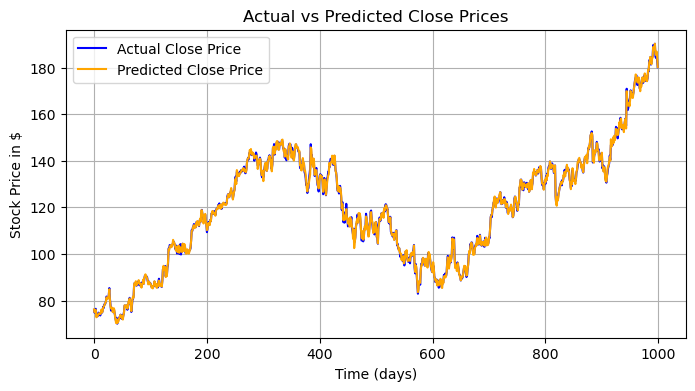

In [209]:
plt.figure(figsize=(8,4))


plt.plot(Y_train.values, label='Actual Close Price', color='blue')

y_temp_pred = model.predict(X_train)

plt.plot(y_temp_pred, label='Predicted Close Price', color='orange')

plt.title('Actual vs Predicted Close Prices')
plt.xlabel('Time (days)')
plt.ylabel('Stock Price in $')
plt.legend()
plt.grid(True)
plt.show()

### Predict today's Closing Price :

In [219]:
# 'Close_t-1','Close_t-2','Close_t-3','Close_t-4','Close_t-5','Volume','High','Low','Open'

ticker = 'GOOGL'
data = yf.download(ticker , period='10d' ,auto_adjust=True)
data.columns = [col[0] for col in data]
data.dropna()

if len(data) < 6 : 
    raise ValueError("Not enough data for a prediction !!! ")

close_t5_to_t1 = list(data['Close'].iloc[-6:-1][::-1])

latest_row = data.iloc[-1]
volume = latest_row['Volume']
volume = latest_row['Volume']
scaled_volume = scaler.transform([[volume]])[0][0]
high = latest_row['High']
low = latest_row['Low']
open_price = latest_row['Open']

featues = close_t5_to_t1 + [scaled_volume, high , low , open_price]

featute_names = ['Close_t-1','Close_t-2','Close_t-3','Close_t-4','Close_t-5','Volume','High','Low','Open']

X_input=pd.DataFrame([featues], columns=featute_names)




[*********************100%***********************]  1 of 1 completed


In [224]:
predicted_close = model.predict(X_input)

print(f"Predicted closing price for the next trading day: ${predicted_close[0]:.2f}")

Predicted closing price for the next trading day: $184.92
